# Colab 9
In this colab, we will investigate the number of COVID cases, officially confirmed by the John Hopkins University, from January 22 2020  to May 18 2021

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pyspark
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark import SparkContext, SparkConf

In [5]:
# create the session
conf = SparkConf().set("spark.ui.port", "4050")

# create the context
sc = pyspark.SparkContext(conf=conf)
spark = SparkSession.builder.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 21:37:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [9]:
confirmed = spark.read.csv('../../assets/datasets/time_series_covid19_confirmed_global.csv', header=True)
deaths = spark.read.csv('../../assets/datasets/time_series_covid19_deaths_global.csv', header=True)
recovered = spark.read.csv('../../assets/datasets/time_series_covid19_recovered_global.csv', header=True)

### May 1 2021

In [10]:
from pyspark.sql import functions as sf
x = confirmed.select("5/1/21")
x.select(sf.sum("5/1/21")).show()

y = deaths.select("5/1/21")
y.select(sf.sum("5/1/21")).show()

z = recovered.select("5/1/21")
z.select(sf.sum("5/1/21")).show()

+------------+
| sum(5/1/21)|
+------------+
|1.52196159E8|
+------------+

+-----------+
|sum(5/1/21)|
+-----------+
|  3192930.0|
+-----------+

+-----------+
|sum(5/1/21)|
+-----------+
|8.8919401E7|
+-----------+



### March 1st

In [11]:
mar1_c = confirmed.where((confirmed["3/1/20"] < 50) & (confirmed["3/1/21"] < 50)).select("Country/Region", "Province/state", "3/1/20", "3/1/21").alias("confirmed")
mar1_d = deaths.where((deaths["3/1/20"] < 50) & (deaths["3/1/21"] < 50)).select("Country/Region", "Province/state", "3/1/20", "3/1/21").withColumnRenamed("3/1/20", "3/1/20-Deaths").withColumnRenamed("3/1/21", "3/1/21-Deaths")

mar1 = mar1_c.join(mar1_d, on=["Province/State", "Country/Region"])
print(mar1.show())

+--------------------+--------------+------+------+-------------+-------------+
|      Province/state|Country/Region|3/1/20|3/1/21|3/1/20-Deaths|3/1/21-Deaths|
+--------------------+--------------+------+------+-------------+-------------+
|    Diamond Princess|        Canada|     0|     0|            0|            1|
|      Grand Princess|        Canada|     0|    13|            0|            0|
|Northwest Territo...|        Canada|     0|    47|            0|            0|
|Repatriated Trave...|        Canada|     0|    13|            0|            0|
|               Macau|         China|    10|    48|            0|            0|
|             Qinghai|         China|    18|    18|            0|            0|
|               Tibet|         China|     1|     1|            0|            0|
|             Unknown|         China|     0|     0|            0|            0|
|           Greenland|       Denmark|     0|    30|            0|            0|
|Saint Pierre and ...|        France|   

In [12]:
mar1_c = confirmed.where((confirmed["3/1/20"] < 50) & (confirmed["3/1/21"] < 50)).select("Country/Region", "Province/state", "3/1/20", "3/1/21").alias("confirmed")
mar1_d = deaths.where((deaths["3/1/20"] < 50) & (deaths["3/1/21"] < 50)).select("Country/Region", "Province/state", "3/1/20", "3/1/21").withColumnRenamed("3/1/20", "3/1/20-Deaths").withColumnRenamed("3/1/21", "3/1/21-Deaths")

mar1 = mar1_c.join(mar1_d, on=["Province/State", "Country/Region"])

mar1 = mar1.withColumn("Death Rate - 3/1/21", sf.try_divide(mar1["3/1/21-Deaths"].cast("int"), mar1["3/1/21"].cast("int")))
mar1 = mar1.withColumn("Death Rate - 3/1/20", sf.try_divide(mar1["3/1/20-Deaths"].cast("int"), mar1["3/1/20"].cast("int")))
print(mar1.show())

+--------------------+--------------+------+------+-------------+-------------+-------------------+-------------------+
|      Province/state|Country/Region|3/1/20|3/1/21|3/1/20-Deaths|3/1/21-Deaths|Death Rate - 3/1/21|Death Rate - 3/1/20|
+--------------------+--------------+------+------+-------------+-------------+-------------------+-------------------+
|    Diamond Princess|        Canada|     0|     0|            0|            1|               NULL|               NULL|
|      Grand Princess|        Canada|     0|    13|            0|            0|                0.0|               NULL|
|Northwest Territo...|        Canada|     0|    47|            0|            0|                0.0|               NULL|
|Repatriated Trave...|        Canada|     0|    13|            0|            0|                0.0|               NULL|
|               Macau|         China|    10|    48|            0|            0|                0.0|                0.0|
|             Qinghai|         China|   

### United Kingdom cases

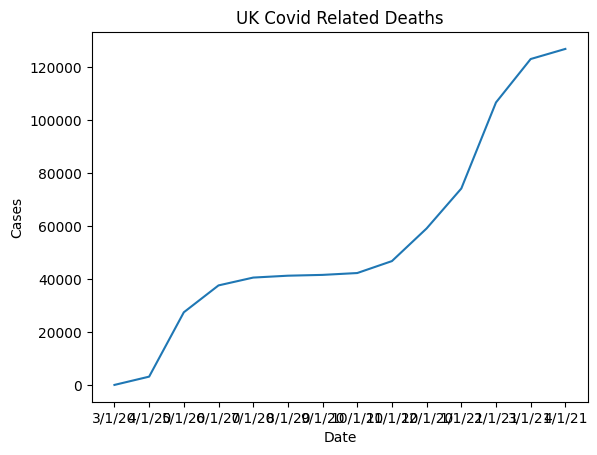

In [40]:
sample_dates = ["3/1/20", "4/1/20", "5/1/20", "6/1/20", "7/1/20", "8/1/20", "9/1/20", "10/1/20", "11/1/20", "12/1/20", "1/1/21", "2/1/21", "3/1/21", "4/1/21"]
uk_cases = deaths.groupby("Country/Region").agg(sf.sum(sample_dates[0]), 
sf.sum(sample_dates[1]), sf.sum(sample_dates[2]), sf.sum(sample_dates[3]),
sf.sum(sample_dates[4]), sf.sum(sample_dates[5]), sf.sum(sample_dates[6]),
sf.sum(sample_dates[7]), sf.sum(sample_dates[8]), sf.sum(sample_dates[9]),
sf.sum(sample_dates[10]), sf.sum(sample_dates[11]), sf.sum(sample_dates[12]),
sf.sum(sample_dates[13])).where(deaths["Country/Region"] == "United Kingdom")

uk = uk_cases.toPandas().iloc[0]
plt.plot(sample_dates,uk.values[1:])
plt.xlabel("Date")
plt.ylabel("Cases")
plt.title("UK Covid Related Deaths")
plt.show()